<a href="https://colab.research.google.com/github/sharmalalbabu266-ctrl/BSC_research_proposal/blob/main/Power%20law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw
from scipy import stats

In [2]:
!pip install powerlaw


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 5.6 MB/s eta 0:00:00


In [3]:
import powerlaw
print(powerlaw.__version__)


2.0.0


In [6]:
csv_path = "nepsealpha_export_price_NEPSE_2021-07-29_2026-07-18_unadjusted.csv"
df = pd.read_csv(csv_path)

In [8]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')


In [9]:
df = df.dropna(subset=['Close'])

In [10]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

In [11]:
returns = df['log_return'].dropna().values

In [12]:
mean = np.mean(returns)
std = np.std(returns)

In [13]:
ks_stat, ks_p = stats.kstest(
returns,
'norm',
args=(mean,std))

In [15]:
if ks_p < 0.05:
    print("The data does not follow a normal distribution.")
else:
    print("The data might follow a normal distribution.")

The data does not follow a normal distribution.


In [16]:
data = np.abs(returns)

In [17]:
data = data[data > 0]

In [18]:
fit = powerlaw.Fit(data, discrete=False)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 1148/1148 [00:01<00:00, 770.13it/s]


In [19]:
print(fit.power_law.alpha)

2.949036357598253


In [20]:
candidates=[
'exponential',
'lognormal',
'truncated_power_law'
]

In [22]:
R,p = fit.distribution_compare('power_law', 'exponential')

<Axes: >

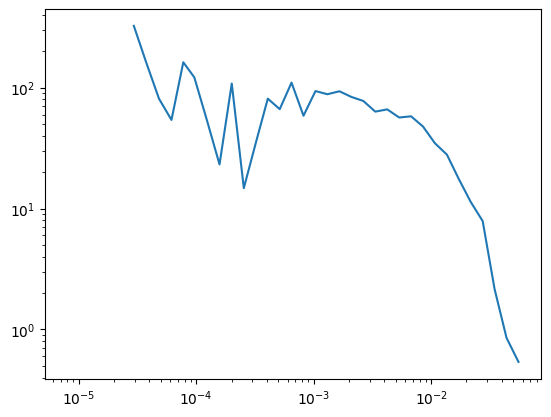

In [23]:
fit.plot_pdf(...)

<Axes: >

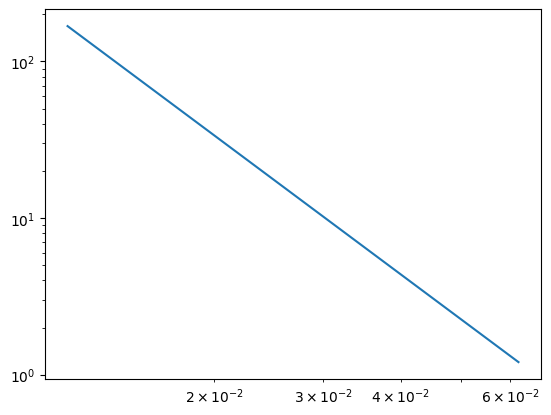

In [24]:
fit.power_law.plot_pdf(...)

<Axes: >

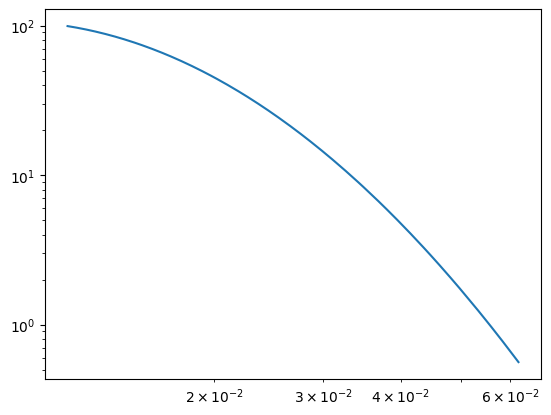

In [25]:
fit.lognormal.plot_pdf(...)

<Axes: >

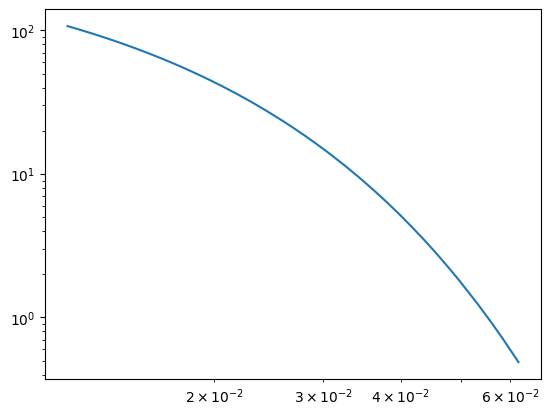

In [26]:
fit.exponential.plot_pdf(...)